
<font color="#CA3532"><h1 align="left">Sistema multimodal para la detección e identificación de especies de hongos mediante visión por computador y modelos de lenguaje</h1></font>
<font color="#6E6E6E"><h2 align="left">Prueba de modelo YOLO26</h2></font> 

#### David Alejandro Pedroza De Jesús

# Carga de librerias

In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix,classification_report, roc_auc_score, roc_curve,ConfusionMatrixDisplay
import seaborn as sns
import torch
from ultralytics import YOLO
import cv2

#   Carga de modelo YOLO26 y algunos datos importantes

In [2]:
rutas_test = pd.read_csv("kaggle/working/test.csv")
info_especies = pd.read_csv("InfoEspecies.csv")
#info_especies = info_especies.drop(info_especies.columns[0], axis= "columns")
resultados = pd.read_csv(r"Modelos\YOLO26\YOLO26\classify\train2\results.csv")
model = YOLO(r"Modelos\YOLO26\YOLO26\classify\train2\weights\best.pt")
test = pd.merge(info_especies, rutas_test, on='label', how='inner')


Ahora voy a obtener predicciones del conjunto de test

In [3]:
def get_prediction(results,labels):
    results_ls = results[0]

    probs = results_ls.probs.data.cpu().numpy()

    prob_img = probs
    pred_img = prob_img.argmax()

    return pred_img, prob_img

In [4]:

labels = info_especies.label.unique()
y_true = []
y_pred = []
y_proba = []
for registro,real_name in zip(test.image_path,test.label):
    img = cv2.imread(registro[1:])
    results = model(img)
    results_ls = results[0]
    y_true.append(int(np.where(labels == real_name)[0][0]))
    pred, prob = get_prediction(results,labels)
    y_pred.append(pred)
    y_proba.append(prob)



0: 256x256 Agaricus augustus 1.00, Lycoperdon pyriforme 0.00, Agaricus xanthodermus 0.00, Suillus granulatus 0.00, Lycoperdon perlatum 0.00, 6.8ms
Speed: 37.9ms preprocess, 6.8ms inference, 0.1ms postprocess per image at shape (1, 3, 256, 256)

0: 256x256 Agaricus augustus 0.95, Amanita rubescens 0.03, Agaricus xanthodermus 0.00, Amanita pantherina 0.00, Chlorophyllum molybdites 0.00, 6.7ms
Speed: 3.6ms preprocess, 6.7ms inference, 0.0ms postprocess per image at shape (1, 3, 256, 256)

0: 256x256 Agaricus augustus 0.90, Agaricus xanthodermus 0.07, Chlorophyllum molybdites 0.01, Amanita phalloides 0.01, Leucoagaricus americanus 0.00, 7.9ms
Speed: 3.2ms preprocess, 7.9ms inference, 0.0ms postprocess per image at shape (1, 3, 256, 256)

0: 256x256 Agaricus augustus 1.00, Leucoagaricus americanus 0.00, Tricholomopsis rutilans 0.00, Agaricus xanthodermus 0.00, Amanita rubescens 0.00, 6.2ms
Speed: 3.2ms preprocess, 6.2ms inference, 0.0ms postprocess per image at shape (1, 3, 256, 256)

0: 2

#   Graficos importantes para determinar el rendimientos
##  Loss

Vemos que la función de perdida del modelo decrece conforme las epocas van pasando, más o menos parece que con 12 epocas de entrenamiento son suficientes, ya que usando más el modelo no mejora.

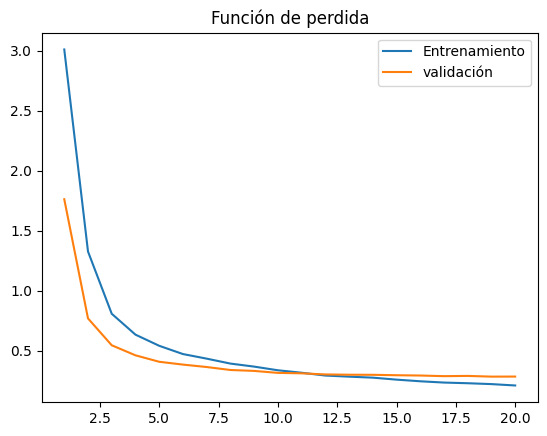

In [5]:
plt.plot(resultados.epoch,resultados["train/loss"], label = "Entrenamiento")
plt.plot(resultados.epoch,resultados["val/loss"], label = "validación")
plt.legend(loc="upper right")
plt.title("Función de perdida")
plt.show()

##  Matriz de confución
### Versión normal
Vemos que además el modelo no parece requerir un ajuste de umbral debido a que todas las clases de predicen con un cierto exito

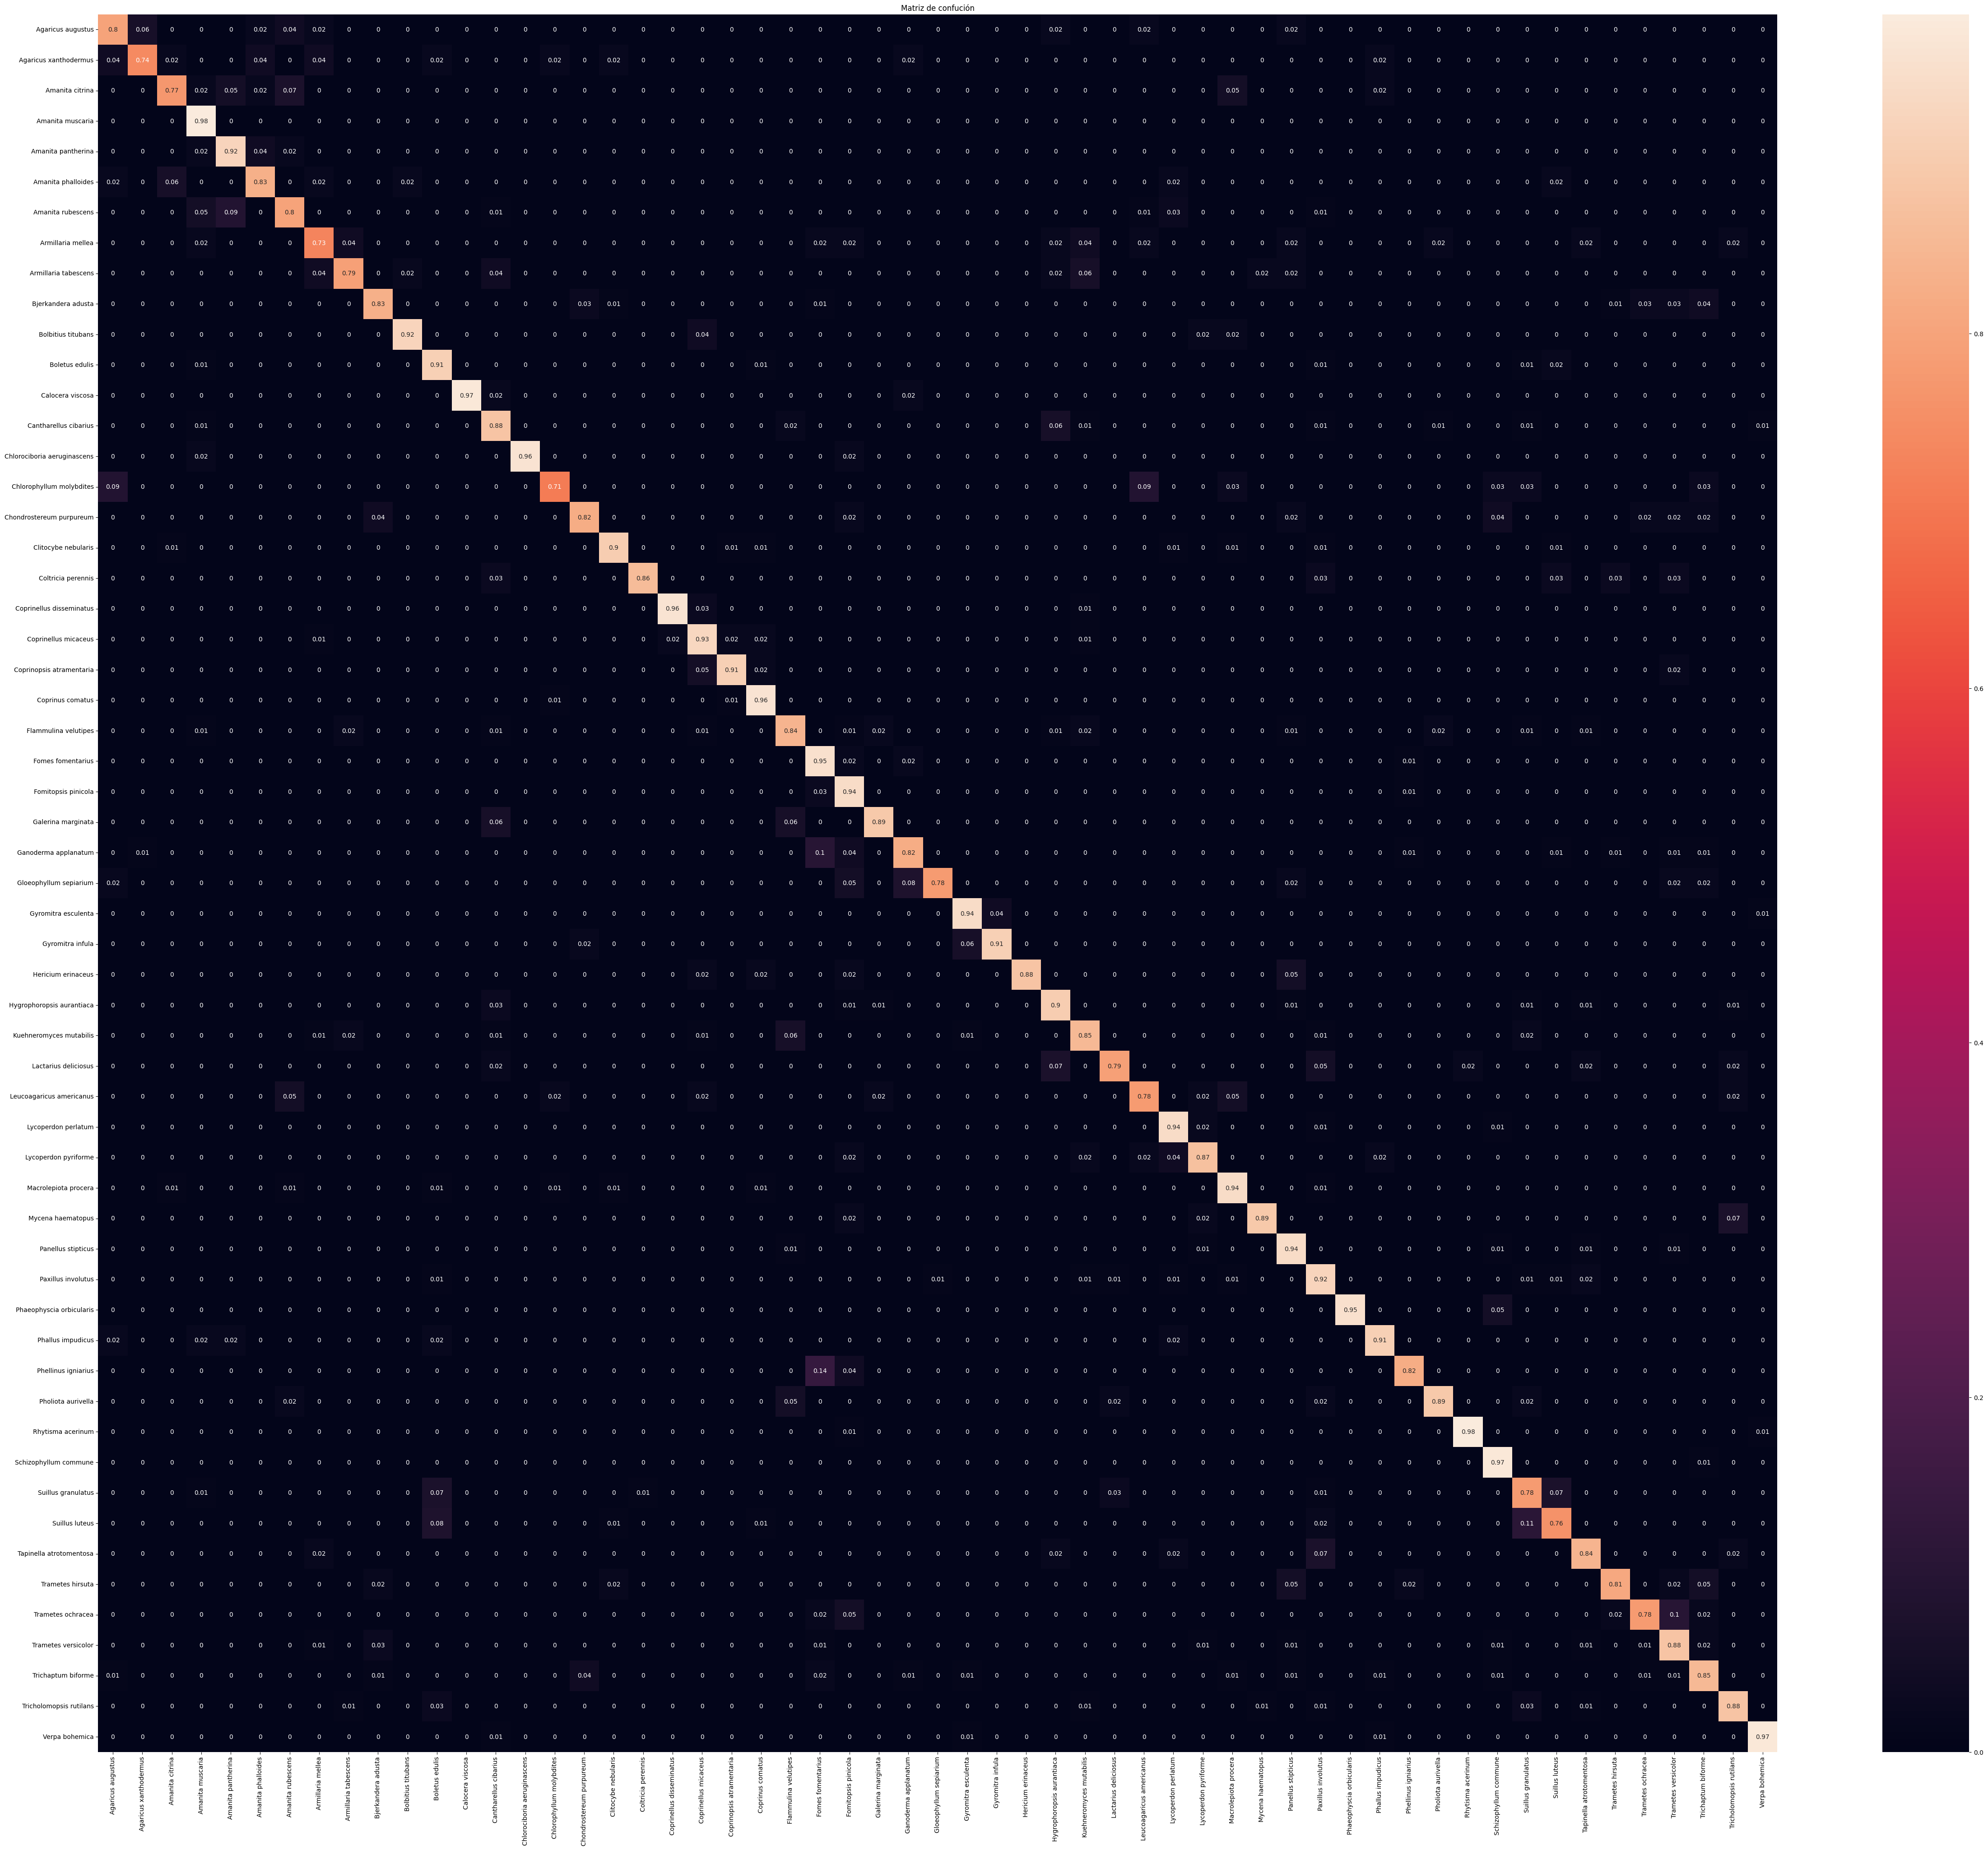

In [7]:
cm = confusion_matrix(y_true, y_pred, normalize= "true").round(2)
plt.subplots(figsize=(60,50))
sns.heatmap(cm,xticklabels= labels, yticklabels= labels,annot=True)
plt.title("Matriz de confución")
plt.show()

### Versión veneno

In [8]:
y_3_true = test.Info
y_3_pre = pd.merge(info_especies, pd.DataFrame(labels[y_pred],columns= ["label"]), on='label', how='inner')["Info"]

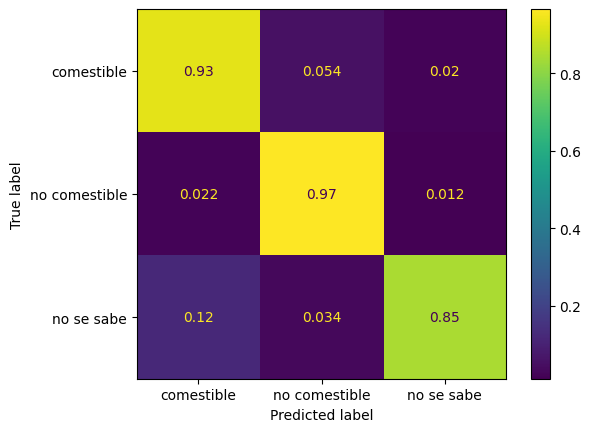

In [13]:
cm_3 = confusion_matrix(y_3_true, y_3_pre, normalize= "true")
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm_3,display_labels= y_3_true.unique())
cm_display.plot()
plt.show()

##  Curva ROC

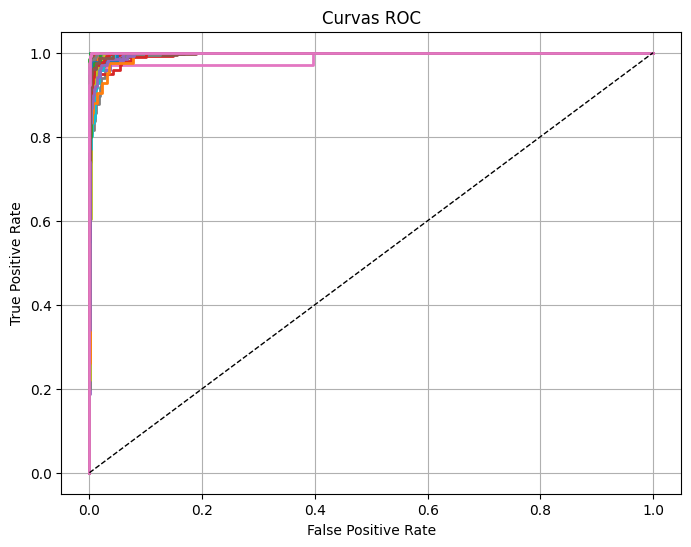

In [14]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
y_proba = np.array(y_proba)
n_classes = y_proba.shape[1]
y_true_bin = label_binarize(y_true, classes=range(n_classes))

plt.figure(figsize=(8,6))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Clase {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curvas ROC')
#plt.legend()
plt.grid(True)
plt.show()

##  Metricas básicas
### Para especies

In [18]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.80      0.81        51
           1       0.85      0.74      0.79        46
           2       0.83      0.77      0.80        44
           3       0.98      0.98      0.98       687
           4       0.78      0.92      0.85        51
           5       0.85      0.83      0.84        48
           6       0.85      0.80      0.82        79
           7       0.78      0.73      0.76        49
           8       0.84      0.79      0.82        53
           9       0.85      0.83      0.84        70
          10       0.96      0.92      0.94        48
          11       0.91      0.91      0.91       220
          12       1.00      0.97      0.98        63
          13       0.88      0.88      0.88       126
          14       1.00      0.96      0.98        51
          15       0.76      0.71      0.74        35
          16       0.78      0.82      0.80        49
          17       0.92    

### Para comestibilidad

In [19]:
print(classification_report(y_3_true, y_3_pre))

               precision    recall  f1-score   support

   comestible       0.93      0.93      0.93      2258
no comestible       0.96      0.97      0.96      3719
   no se sabe       0.86      0.85      0.85       671

     accuracy                           0.94      6648
    macro avg       0.92      0.91      0.91      6648
 weighted avg       0.94      0.94      0.94      6648

